<a href="https://colab.research.google.com/github/salikb7/Machine-Learning-on-Big-Data-/blob/main/Perceptron_Assessment_Lab_Spambase_week8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Salik Ram Bhandari
#Id= 3260364
# Perceptron Learning Algorithm: Assessment Lab Classifying Spam vs Non-Spam Email using PySpark

## Lab structure

1. Environment setup
2. Load the raw dataset and understand why adaptation is required
3. Engineer Spambase-style numerical features from the raw text (PySpark)
4. Data exploration on the engineered features
5. Exploratory visualisation
6. Assemble, split and scale the features (leakage-free)
7. Manual Perceptron implementation
8. Training diagnostics
9. Test-set evaluation
10. Feature-importance inspection
11. Comparison with scikit-learn





#1. Install PySpark

In [5]:
!pip install -q pyspark

# 2. Import required libraries

In [41]:

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pyspark.sql import SparkSession
from pyspark.sql.functions import col, count, when, isnan, udf, length
from pyspark.sql.types import ArrayType, DoubleType
from pyspark.ml.feature import VectorAssembler, StandardScaler

from sklearn.decomposition import PCA
from sklearn.linear_model import Perceptron as SklearnPerceptron
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries imported successfully.")

Libraries imported successfully.


# 3. Create a Spark session

In [42]:

spark = (
    SparkSession.builder
    .appName("Perceptron_Assessment_Lab_Spambase")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("ERROR")

print("Spark version:", spark.version)

Spark version: 4.0.3


## 4. Load the raw email dataset

In [44]:

pdf_raw = pd.read_csv("emails.csv")

print("Raw shape:", pdf_raw.shape)
pdf_raw.head()

Raw shape: (5728, 2)


,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1


5. Move the raw data into a Spark DataFrame

In [45]:

raw_df = spark.createDataFrame(pdf_raw)

print("Schema of the raw Spark DataFrame")
raw_df.printSchema()

print("\nRow count:", raw_df.count())

print("\nClass distribution (raw)")
raw_df.groupBy("spam").count().orderBy("spam").show()

print("\nMissing / null values")
raw_df.select([
    count(when(col(c).isNull(), c)).alias(c)
    for c in raw_df.columns
]).show()

Schema of the raw Spark DataFrame
root
 |-- text: string (nullable = true)
 |-- spam: long (nullable = true)


Row count: 5728

Class distribution (raw)
+----+-----+
|spam|count|
+----+-----+
|   0| 4360|
|   1| 1368|
+----+-----+


Missing / null values
+----+----+
|text|spam|
+----+----+
|   0|   0|
+----+----+



# 6. Inspect the raw text a little further


In [49]:

length_df = raw_df.withColumn("char_length", length(col("text")))

print("Email character-length summary")
length_df.select("char_length").describe().show()

raw_df.select("text", "spam").show(3, truncate=120)

Email character-length summary
+-------+------------------+
|summary|       char_length|
+-------+------------------+
|  count|              5728|
|   mean|1556.7686801675977|
| stddev|2042.6498121362586|
|    min|                13|
|    max|             43952|
+-------+------------------+

+------------------------------------------------------------------------------------------------------------------------+----+
|                                                                                                                    text|spam|
+------------------------------------------------------------------------------------------------------------------------+----+
|Subject: naturally irresistible your corporate identity  lt is really hard to recollect a company : the  market is fu...|   1|
|Subject: the stock trading gunslinger  fanny is merrill but muzo not colza attainder and penultimate like esmark pers...|   1|
|Subject: unbelievable new homes made easy  im wanting to show you 

#7. Define the 48 words and 6 characters used by Spambase

In [50]:

SPAMBASE_WORDS = [
    "make", "address", "all", "3d", "our", "over", "remove", "internet",
    "order", "mail", "receive", "will", "people", "report", "addresses",
    "free", "business", "email", "you", "credit", "your", "font", "000",
    "money", "hp", "hpl", "george", "650", "lab", "labs", "telnet", "857",
    "data", "415", "85", "technology", "1999", "parts", "pm", "direct",
    "cs", "meeting", "original", "project", "re", "edu", "table",
    "conference",
]

SPAMBASE_CHARS = [";", "(", "[", "!", "$", "#"]
CHAR_NAMES = ["semicolon", "paren", "bracket", "exclamation", "dollar", "hash"]

feature_columns = (
    [f"word_freq_{w}" for w in SPAMBASE_WORDS]
    + [f"char_freq_{n}" for n in CHAR_NAMES]
    + ["capital_run_length_average", "capital_run_length_longest", "capital_run_length_total"]
)

print("Number of word features :", len(SPAMBASE_WORDS))
print("Number of char features :", len(SPAMBASE_CHARS))
print("Total engineered features:", len(feature_columns))
assert len(feature_columns) == 57

Number of word features : 48
Number of char features : 6
Total engineered features: 57


#8. PySpark UDF: turn raw email text into the 57 Spambase-style values

In [51]:

def extract_spambase_features(text):
    body = text if text is not None else ""

    # The "Subject:" prefix is a dataset artefact, not part of the message.
    if body.lower().startswith("subject:"):
        body = body[len("subject:"):]

    tokens = re.findall(r"[A-Za-z0-9]+", body)
    total_words = len(tokens) if len(tokens) > 0 else 1
    lower_tokens = [t.lower() for t in tokens]

    word_feats = [
        100.0 * sum(1 for t in lower_tokens if t == w) / total_words
        for w in SPAMBASE_WORDS
    ]

    total_chars = len(body) if len(body) > 0 else 1
    char_feats = [100.0 * body.count(ch) / total_chars for ch in SPAMBASE_CHARS]

    capital_runs = [len(r) for r in re.findall(r"[A-Z]+", body)]
    if capital_runs:
        cap_avg = float(sum(capital_runs) / len(capital_runs))
        cap_longest = float(max(capital_runs))
        cap_total = float(sum(capital_runs))
    else:
        cap_avg, cap_longest, cap_total = 0.0, 0.0, 0.0

    return word_feats + char_feats + [cap_avg, cap_longest, cap_total]


extract_udf = udf(extract_spambase_features, ArrayType(DoubleType()))

engineered_df = raw_df.withColumn("feature_array", extract_udf(col("text")))

for i, name in enumerate(feature_columns):
    engineered_df = engineered_df.withColumn(name, engineered_df["feature_array"].getItem(i))

engineered_df = engineered_df.drop("feature_array", "text")
engineered_df = engineered_df.withColumnRenamed("spam", "Class")
engineered_df = engineered_df.cache()

print("Engineered dataset row count:", engineered_df.count())
engineered_df.select(feature_columns[:6] + ["Class"]).show(5)

Engineered dataset row count: 5728
+------------------+-----------------+------------------+------------+------------------+--------------+-----+
|    word_freq_make|word_freq_address|     word_freq_all|word_freq_3d|     word_freq_our|word_freq_over|Class|
+------------------+-----------------+------------------+------------+------------------+--------------+-----+
|1.0638297872340425|              0.0|0.5319148936170213|         0.0|0.5319148936170213|           0.0|    1|
|               0.0|              0.0|               0.0|         0.0|               0.0|           0.0|    1|
|               0.0|              0.0|1.2658227848101267|         0.0|1.2658227848101267|           0.0|    1|
|               0.0|              0.0|               0.0|         0.0|  2.73972602739726|           0.0|    1|
|               0.0|              0.0| 5.128205128205129|         0.0|               0.0|           0.0|    1|
+------------------+-----------------+------------------+------------+-------

#9. Inspect the engineered dataset

In [52]:

print("Schema (first 10 fields shown)")
engineered_df.select(feature_columns[:10]).printSchema()

row_count = engineered_df.count()
column_count = len(engineered_df.columns)

print("\nDimensions")
print("Rows   :", row_count)
print("Columns:", column_count, "(57 engineered features + Class)")

print("\nClass distribution")
engineered_df.groupBy("Class").count().orderBy("Class").show()

print("\nMissing values across engineered features")
engineered_df.select([
    count(when(col(c).isNull() | isnan(c), c)).alias(c)
    for c in feature_columns
]).select(feature_columns[:8]).show()

Schema (first 10 fields shown)
root
 |-- word_freq_make: double (nullable = true)
 |-- word_freq_address: double (nullable = true)
 |-- word_freq_all: double (nullable = true)
 |-- word_freq_3d: double (nullable = true)
 |-- word_freq_our: double (nullable = true)
 |-- word_freq_over: double (nullable = true)
 |-- word_freq_remove: double (nullable = true)
 |-- word_freq_internet: double (nullable = true)
 |-- word_freq_order: double (nullable = true)
 |-- word_freq_mail: double (nullable = true)


Dimensions
Rows   : 5728
Columns: 58 (57 engineered features + Class)

Class distribution
+-----+-----+
|Class|count|
+-----+-----+
|    0| 4360|
|    1| 1368|
+-----+-----+


Missing values across engineered features
+--------------+-----------------+-------------+------------+-------------+--------------+----------------+------------------+
|word_freq_make|word_freq_address|word_freq_all|word_freq_3d|word_freq_our|word_freq_over|word_freq_remove|word_freq_internet|
+--------------+--------

#10. Summary statistics for a subset of informative features
 All 57 columns at once is unwieldy to read, so a handful of the features most associated with spam in the original dataset are shown.


In [53]:

highlight_features = [
    "word_freq_free", "word_freq_money", "word_freq_remove",
    "word_freq_your", "char_freq_exclamation", "char_freq_dollar",
    "capital_run_length_total",
]

engineered_df.select(highlight_features + ["Class"]).describe().show()

+-------+-------------------+-------------------+--------------------+------------------+---------------------+--------------------+------------------------+-------------------+
|summary|     word_freq_free|    word_freq_money|    word_freq_remove|    word_freq_your|char_freq_exclamation|    char_freq_dollar|capital_run_length_total|              Class|
+-------+-------------------+-------------------+--------------------+------------------+---------------------+--------------------+------------------------+-------------------+
|  count|               5728|               5728|                5728|              5728|                 5728|                5728|                    5728|               5728|
|   mean|0.10465766481986023| 0.0623390889165093|0.021136892069361916|0.9502042638398909|  0.10489715131522315|0.046399681670570535|                     0.0| 0.2388268156424581|
| stddev|  0.510122560048945|0.33019074976210155|  0.1579857254750556|1.6154695467567521|   0.3076052235850778

# 11. Visual 1: Class distribution

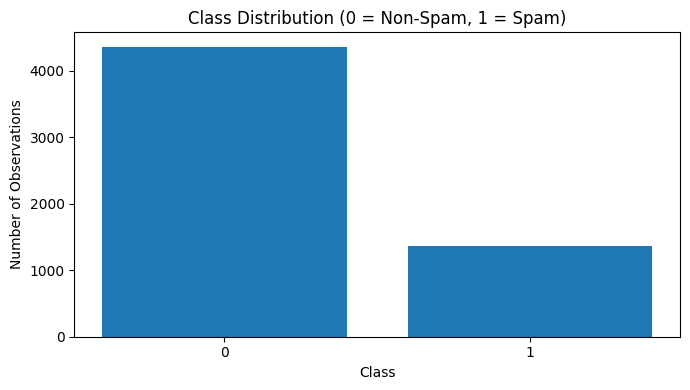

Class
0    4360
1    1368
Name: count, dtype: int64


In [54]:

pdf_eng = engineered_df.toPandas()

class_counts = pdf_eng["Class"].value_counts().sort_index()

plt.figure(figsize=(7, 4))
plt.bar(class_counts.index.astype(str), class_counts.values)
plt.title("Class Distribution (0 = Non-Spam, 1 = Spam)")
plt.xlabel("Class")
plt.ylabel("Number of Observations")
plt.tight_layout()
plt.show()

print(class_counts)

# 12. Visuals 2-7: Distribution of key word/char features by class

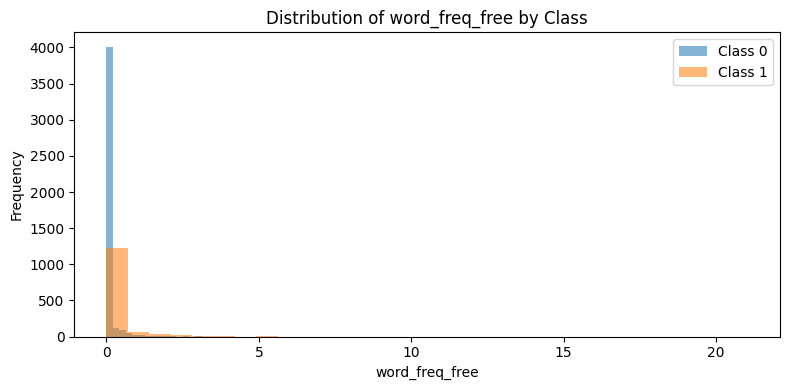

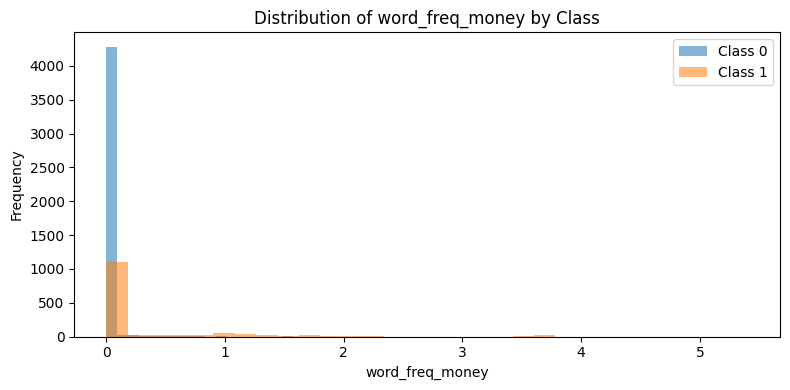

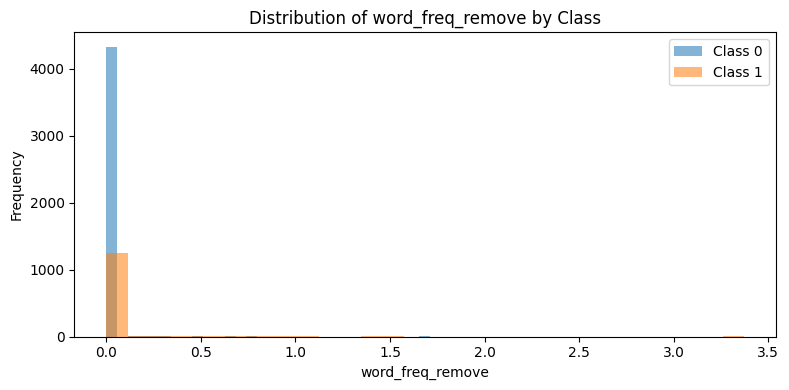

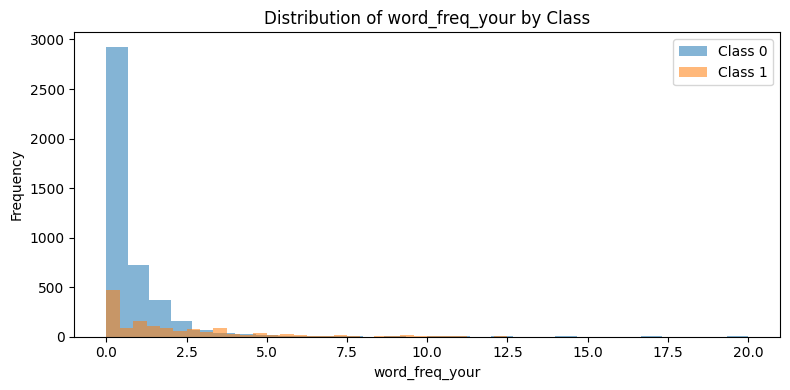

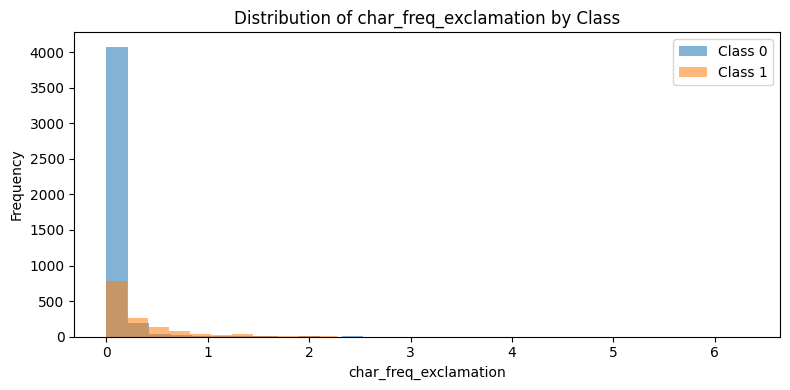

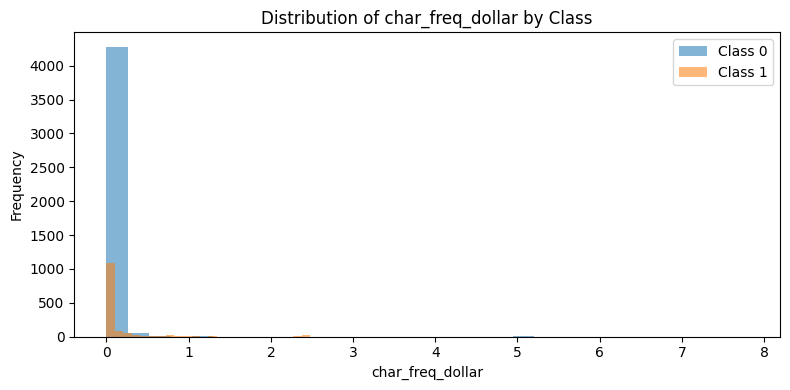

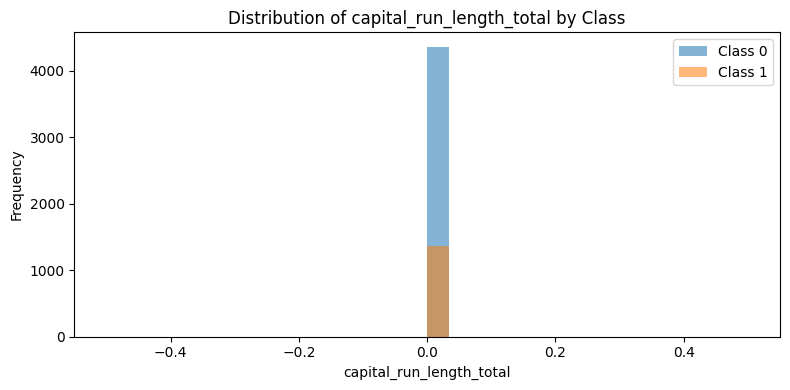

In [55]:

for feature in highlight_features:
    plt.figure(figsize=(8, 4))

    for class_value in sorted(pdf_eng["Class"].unique()):
        values = pdf_eng.loc[pdf_eng["Class"] == class_value, feature]
        plt.hist(values, bins=30, alpha=0.55, label=f"Class {class_value}")

    plt.title(f"Distribution of {feature} by Class")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.legend()
    plt.tight_layout()
    plt.show()

# 13. Visual 8: Correlation matrix of the highlighted features
Correlation across all 57 raw features is difficult to read, so the small highlighted subset (plus Class) is used here.

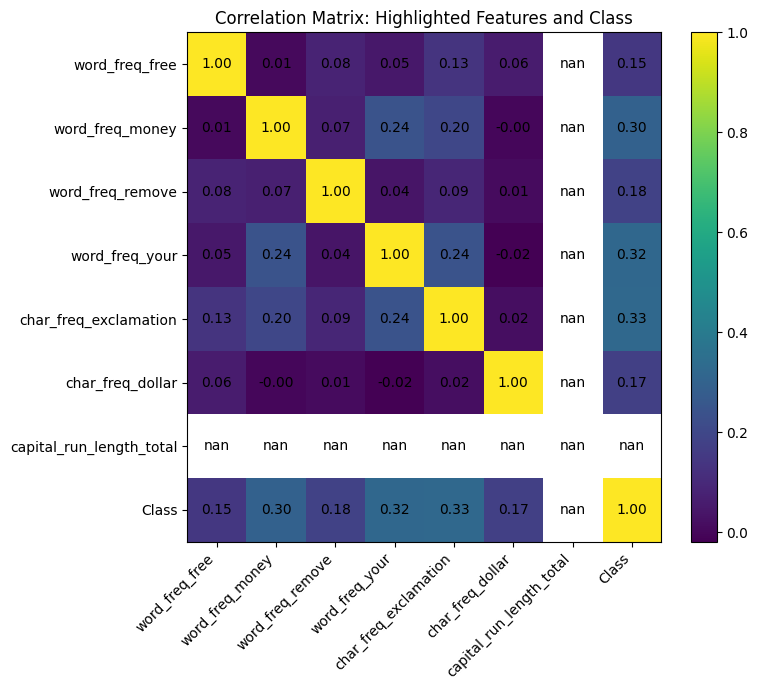

In [56]:

corr_features = highlight_features + ["Class"]
correlation_matrix = pdf_eng[corr_features].corr()

plt.figure(figsize=(8, 7))
image = plt.imshow(correlation_matrix, aspect="auto")
plt.colorbar(image)

tick_positions = np.arange(len(corr_features))
plt.xticks(tick_positions, corr_features, rotation=45, ha="right")
plt.yticks(tick_positions, corr_features)

for row in range(correlation_matrix.shape[0]):
    for column in range(correlation_matrix.shape[1]):
        plt.text(
            column, row, f"{correlation_matrix.iloc[row, column]:.2f}",
            ha="center", va="center",
        )

plt.title("Correlation Matrix: Highlighted Features and Class")
plt.tight_layout()
plt.show()

# 14. Assemble the raw feature vector

In [57]:

assembler = VectorAssembler(
    inputCols=feature_columns,
    outputCol="features",
)

assembled_data = assembler.transform(engineered_df)

assembled_data.select("features", "Class").show(5, truncate=80)

+--------------------------------------------------------------------------------+-----+
|                                                                        features|Class|
+--------------------------------------------------------------------------------+-----+
|(57,[0,2,4,11,16,18,20,42,48],[1.0638297872340425,0.5319148936170213,0.531914...|    1|
|                                                                      (57,[],[])|    1|
|(57,[2,4,18,19,20,52],[1.2658227848101267,1.2658227848101267,6.32911392405063...|    1|
|(57,[4,8,9,49,51],[2.73972602739726,2.73972602739726,2.73972602739726,0.81300...|    1|
|       (57,[2,23,51],[5.128205128205129,2.5641025641025643,0.44052863436123346])|    1|
+--------------------------------------------------------------------------------+-----+
only showing top 5 rows


# 15. Split BEFORE fitting the scaler

In [58]:

train_raw, test_raw = assembled_data.randomSplit(
    [0.80, 0.20],
    seed=RANDOM_STATE,
)

train_raw = train_raw.cache()
test_raw = test_raw.cache()

train_count = train_raw.count()
test_count = test_raw.count()

print("Training observations:", train_count)
print("Test observations    :", test_count)
print("Total                :", train_count + test_count)

Training observations: 4648
Test observations    : 1080
Total                : 5728


# 16. Fit the scaler only on the training data

In [59]:

scaler = StandardScaler(
    inputCol="features",
    outputCol="scaledFeatures",
    withMean=True,
    withStd=True,
)

scaler_model = scaler.fit(train_raw)

train_df = scaler_model.transform(train_raw)
test_df = scaler_model.transform(test_raw)

print("Training data after scaling")
train_df.select("scaledFeatures", "Class").show(5, truncate=80)

Training data after scaling
+--------------------------------------------------------------------------------+-----+
|                                                                  scaledFeatures|Class|
+--------------------------------------------------------------------------------+-----+
|[-0.3150031575154849,-0.2143694645710413,-0.38799096765480856,0.0,-0.50852653...|    0|
|[-0.3150031575154849,-0.2143694645710413,-0.38799096765480856,0.0,-0.50852653...|    0|
|[-0.3150031575154849,-0.2143694645710413,-0.38799096765480856,0.0,-0.50852653...|    0|
|[-0.3150031575154849,-0.2143694645710413,-0.38799096765480856,0.0,-0.50852653...|    0|
|[-0.3150031575154849,-0.2143694645710413,-0.38799096765480856,0.0,-0.50852653...|    0|
+--------------------------------------------------------------------------------+-----+
only showing top 5 rows


# 17. Inspect the learned scaling parameters (first 10 features)

In [61]:

scaling_parameters = pd.DataFrame({
    "Feature": feature_columns,
    "Training Mean": scaler_model.mean.toArray(),
    "Training Standard Deviation": scaler_model.std.toArray(),
})

print(scaling_parameters.head(10).to_string(index=False))

           Feature  Training Mean  Training Standard Deviation
    word_freq_make       0.107711                     0.341938
 word_freq_address       0.065522                     0.305651
     word_freq_all       0.217388                     0.560291
      word_freq_3d       0.000000                     0.000000
     word_freq_our       0.363936                     0.715668
    word_freq_over       0.091437                     0.355840
  word_freq_remove       0.019735                     0.153834
word_freq_internet       0.038072                     0.223972
   word_freq_order       0.070290                     0.383930
    word_freq_mail       0.137834                     0.455077


# 18. Collect the prepared dataset into NumPy arrays
 collect() moves data to the Spark driver. This is acceptable here because the dataset (a few thousand rows, 57 features) is small. It would not be appropriate for a genuinely large dataset.

In [63]:

def spark_frame_to_numpy(frame):
    rows = frame.select("scaledFeatures", "Class").collect()

    X = np.array([row["scaledFeatures"].toArray() for row in rows])

    # Convert original labels 0/1 into perceptron labels -1/+1.
    y = np.array([1 if int(row["Class"]) == 1 else -1 for row in rows])

    return X, y


X_train, y_train = spark_frame_to_numpy(train_df)
X_test, y_test = spark_frame_to_numpy(test_df)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("Training labels:", np.unique(y_train, return_counts=True))
print("Test labels    :", np.unique(y_test, return_counts=True))
print("Any NaNs in X_train:", np.isnan(X_train).any())
print("Any NaNs in X_test :", np.isnan(X_test).any())

X_train shape: (4648, 57)
X_test shape : (1080, 57)
Training labels: (array([-1,  1]), array([3547, 1101]))
Test labels    : (array([-1,  1]), array([813, 267]))
Any NaNs in X_train: False
Any NaNs in X_test : False


# 19. Visual 9: PCA projection of the scaled training data
PCA is used only to visualise the 57-dimensional data in two dimensions.


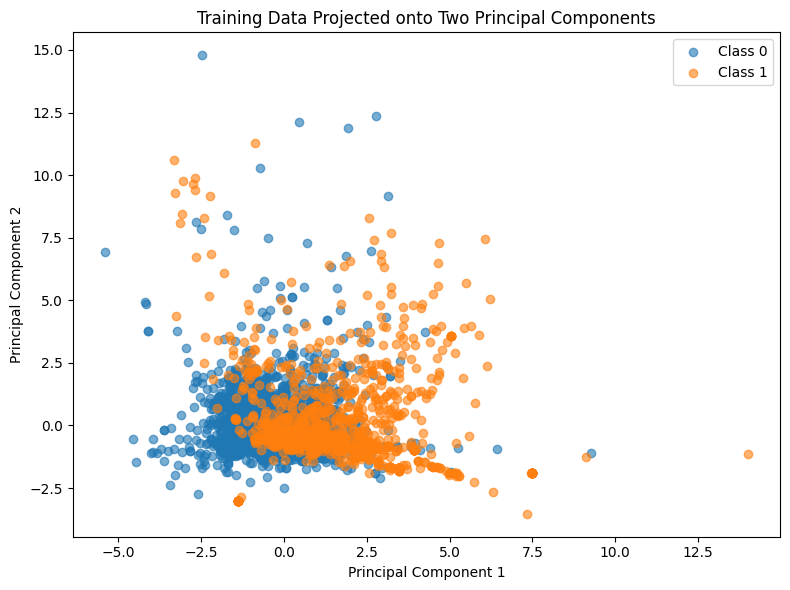

Explained variance: [0.0437 0.0349]


In [64]:

pca_for_view = PCA(n_components=2)
X_train_pca = pca_for_view.fit_transform(X_train)

plt.figure(figsize=(8, 6))

for label in (-1, 1):
    mask = y_train == label
    plt.scatter(
        X_train_pca[mask, 0],
        X_train_pca[mask, 1],
        label=f"Class {0 if label == -1 else 1}",
        alpha=0.6,
    )

plt.title("Training Data Projected onto Two Principal Components")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.tight_layout()
plt.show()

print("Explained variance:", np.round(pca_for_view.explained_variance_ratio_, 4))

# 20. Manual perceptron implementation


In [66]:

class ManualPerceptron:
    def __init__(self, learning_rate=0.01, epochs=100, shuffle=True, random_state=42):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.shuffle = shuffle
        self.random_state = random_state

    @staticmethod
    def activation(score):
        return np.where(score >= 0, 1, -1)

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=int)

        if set(np.unique(y)) - {-1, 1}:
            raise ValueError("The perceptron labels must be -1 or +1.")

        rng = np.random.default_rng(self.random_state)

        self.weights_ = np.zeros(X.shape[1], dtype=float)
        self.bias_ = 0.0

        self.errors_per_epoch_ = []
        self.weights_history_ = []
        self.bias_history_ = []

        self.best_errors_ = np.inf
        self.best_weights_ = self.weights_.copy()
        self.best_bias_ = self.bias_
        self.best_epoch_ = 0
        self.converged_ = False

        for epoch in range(self.epochs):
            indices = np.arange(X.shape[0])

            if self.shuffle:
                rng.shuffle(indices)

            errors = 0

            for index in indices:
                sample = X[index]
                target = y[index]

                score = np.dot(sample, self.weights_) + self.bias_
                prediction = 1 if score >= 0 else -1

                if prediction != target:
                    update = self.learning_rate * target
                    self.weights_ += update * sample
                    self.bias_ += update
                    errors += 1

            self.errors_per_epoch_.append(errors)
            self.weights_history_.append(self.weights_.copy())
            self.bias_history_.append(self.bias_)

            if errors < self.best_errors_:
                self.best_errors_ = errors
                self.best_weights_ = self.weights_.copy()
                self.best_bias_ = self.bias_
                self.best_epoch_ = epoch + 1

            if errors == 0:
                self.converged_ = True
                break

        self.weights_history_ = np.asarray(self.weights_history_)
        self.bias_history_ = np.asarray(self.bias_history_)

        return self

    def decision_function(self, X, use_pocket=False):
        X = np.asarray(X, dtype=float)

        if use_pocket:
            weights = self.best_weights_
            bias = self.best_bias_
        else:
            weights = self.weights_
            bias = self.bias_

        return X @ weights + bias

    def predict(self, X, use_pocket=False):
        scores = self.decision_function(X, use_pocket=use_pocket)
        return self.activation(scores)

# 21. Train the manual perceptron

In [67]:

model = ManualPerceptron(
    learning_rate=0.01,
    epochs=100,
    shuffle=True,
    random_state=RANDOM_STATE,
)

model.fit(X_train, y_train)

print("Epochs completed       :", len(model.errors_per_epoch_))
print("Converged              :", model.converged_)
print("Best training errors   :", model.best_errors_)
print("Best epoch             :", model.best_epoch_)
print("Final bias             :", round(model.bias_, 4))
print("Pocket bias            :", round(model.best_bias_, 4))

if not model.converged_:
    print(
        "\nThe training errors did not reach zero. "
        "This is consistent with non-separable or noisy data, which is "
        "expected for a 57-feature bag-of-words-style representation of "
        "real email text."
    )

Epochs completed       : 100
Converged              : False
Best training errors   : 647
Best epoch             : 21
Final bias             : -0.56
Pocket bias            : -0.7

The training errors did not reach zero. This is consistent with non-separable or noisy data, which is expected for a 57-feature bag-of-words-style representation of real email text.


# 22. Visual 10: Misclassifications per epoch

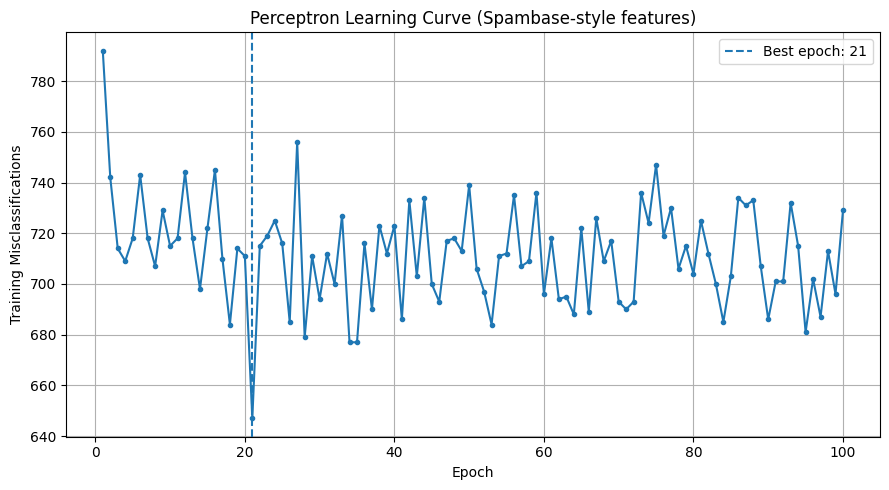

In [68]:

epochs_completed = np.arange(1, len(model.errors_per_epoch_) + 1)

plt.figure(figsize=(9, 5))
plt.plot(epochs_completed, model.errors_per_epoch_, marker="o", markersize=3)
plt.axvline(model.best_epoch_, linestyle="--", label=f"Best epoch: {model.best_epoch_}")
plt.title("Perceptron Learning Curve (Spambase-style features)")
plt.xlabel("Epoch")
plt.ylabel("Training Misclassifications")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 23. Visual 11: Weight trajectories for the 10 most influential features
 With 57 features, plotting every weight trajectory is unreadable, so only the 10 features with the largest final pocket weight (by magnitude) are shown.


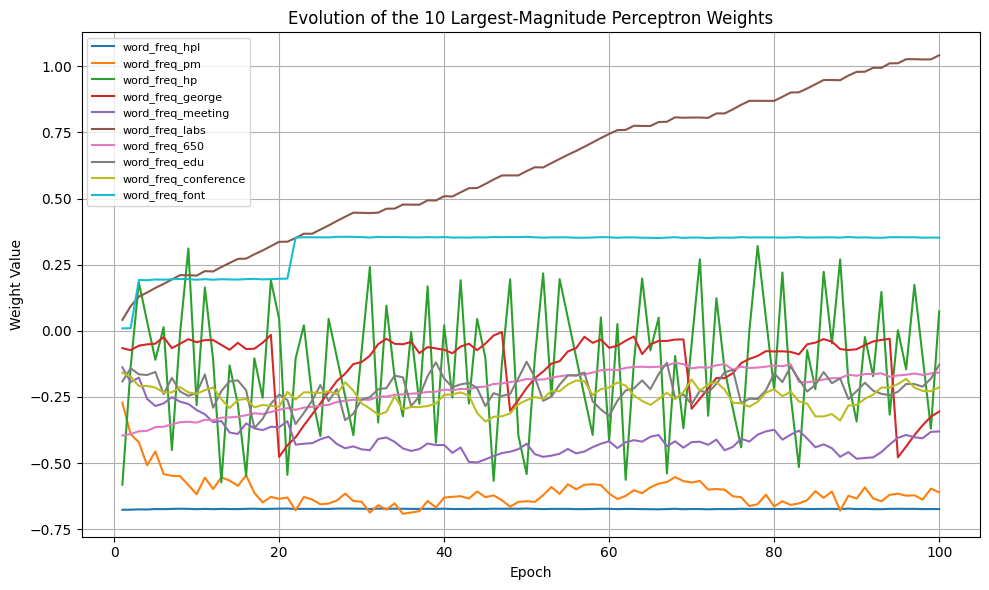

In [69]:


final_abs_weight = np.abs(model.best_weights_)
top_indices = np.argsort(final_abs_weight)[::-1][:10]

plt.figure(figsize=(10, 6))
for idx in top_indices:
    plt.plot(epochs_completed, model.weights_history_[:, idx], label=feature_columns[idx])

plt.title("Evolution of the 10 Largest-Magnitude Perceptron Weights")
plt.xlabel("Epoch")
plt.ylabel("Weight Value")
plt.legend(fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()

# 24. Visual 12: Bias trajectory

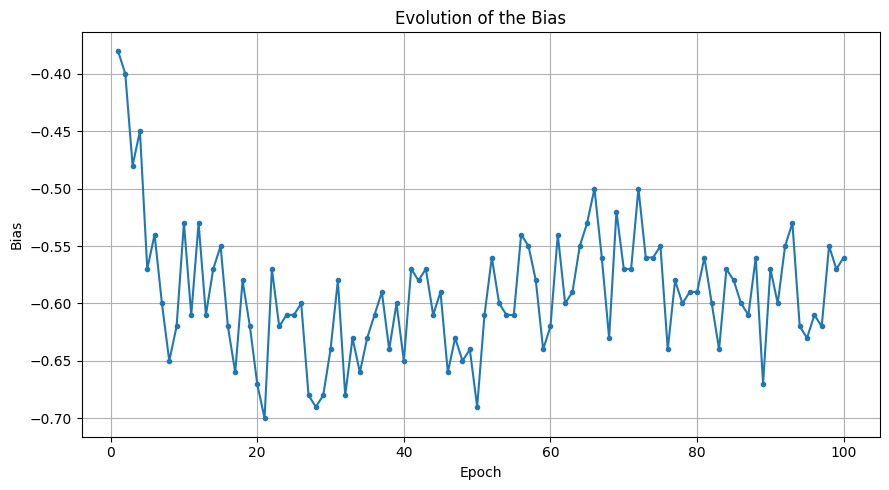

In [71]:

plt.figure(figsize=(9, 5))
plt.plot(epochs_completed, model.bias_history_, marker="o", markersize=3)
plt.title("Evolution of the Bias")
plt.xlabel("Epoch")
plt.ylabel("Bias")
plt.grid(True)
plt.tight_layout()
plt.show()

#25. Generate test predictions


In [72]:

y_pred_pocket = model.predict(X_test, use_pocket=True)
y_pred_final = model.predict(X_test, use_pocket=False)

print("First 15 test predictions")
prediction_preview = pd.DataFrame({
    "Actual": y_test[:15],
    "Pocket prediction": y_pred_pocket[:15],
    "Final-epoch prediction": y_pred_final[:15],
})

print(prediction_preview.to_string(index=False))

First 15 test predictions
 Actual  Pocket prediction  Final-epoch prediction
     -1                 -1                      -1
     -1                 -1                      -1
     -1                 -1                      -1
     -1                 -1                      -1
     -1                 -1                      -1
     -1                 -1                      -1
     -1                 -1                      -1
     -1                 -1                      -1
     -1                  1                      -1
     -1                  1                      -1
     -1                  1                      -1
     -1                 -1                      -1
     -1                 -1                      -1
     -1                 -1                      -1
     -1                 -1                      -1


# 26. Calculate classification metrics

In [73]:

def metric_summary(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "Recall": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "F1": f1_score(y_true, y_pred, pos_label=1, zero_division=0),
    }


pocket_metrics = metric_summary(y_test, y_pred_pocket)
final_metrics = metric_summary(y_test, y_pred_final)

metrics_table = pd.DataFrame({
    "Pocket model": pocket_metrics,
    "Final-epoch model": final_metrics,
}).T

print(metrics_table.round(4).to_string())

                   Accuracy  Precision  Recall      F1
Pocket model         0.8546     0.7331  0.6479  0.6879
Final-epoch model    0.8583     0.7192  0.7004  0.7097


# 27. Visual 13: Performance metrics

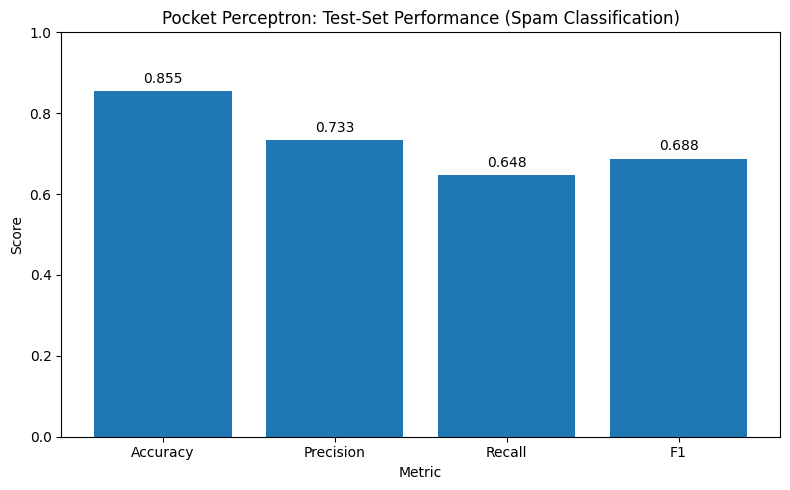

In [74]:

metric_names = list(pocket_metrics.keys())
metric_values = list(pocket_metrics.values())

plt.figure(figsize=(8, 5))
plt.bar(metric_names, metric_values)
plt.ylim(0, 1)
plt.title("Pocket Perceptron: Test-Set Performance (Spam Classification)")
plt.xlabel("Metric")
plt.ylabel("Score")

for index, value in enumerate(metric_values):
    plt.text(index, value + 0.02, f"{value:.3f}", ha="center")

plt.tight_layout()
plt.show()

# 28. Classification report

In [32]:

print(
    classification_report(
        y_test,
        y_pred_pocket,
        labels=[-1, 1],
        target_names=["Non-Spam (0)", "Spam (1)"],
        zero_division=0,
    )
)

              precision    recall  f1-score   support

Non-Spam (0)       0.89      0.92      0.91       813
    Spam (1)       0.73      0.65      0.69       267

    accuracy                           0.85      1080
   macro avg       0.81      0.79      0.80      1080
weighted avg       0.85      0.85      0.85      1080



# 29. Visual 14: Confusion matrix

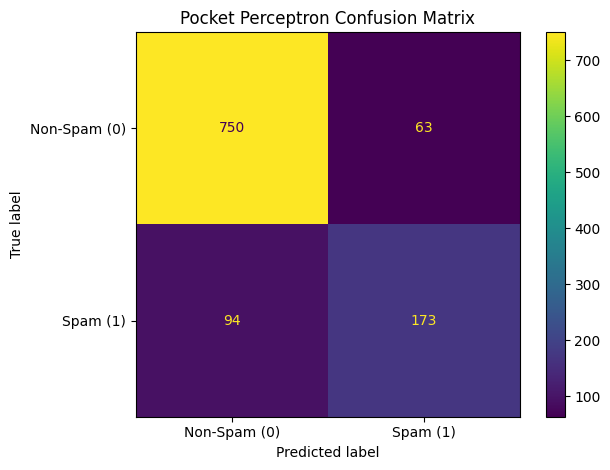

In [75]:

cm = confusion_matrix(y_test, y_pred_pocket, labels=[-1, 1])

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Spam (0)", "Spam (1)"],
)

display.plot()
plt.title("Pocket Perceptron Confusion Matrix")
plt.tight_layout()
plt.show()

# 30. Visual 15: Decision-score distributions
Distance from zero indicates the model's signed confidence, but it is not a calibrated probability.

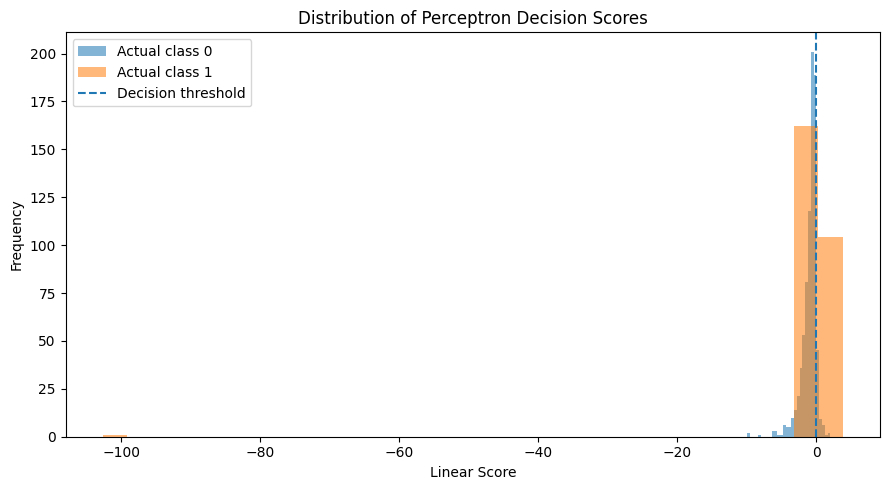

In [76]:

test_scores = model.decision_function(X_test, use_pocket=True)

plt.figure(figsize=(9, 5))

for label in (-1, 1):
    plt.hist(test_scores[y_test == label], bins=30, alpha=0.55,
              label=f"Actual class {0 if label == -1 else 1}")

plt.axvline(0, linestyle="--", label="Decision threshold")
plt.title("Distribution of Perceptron Decision Scores")
plt.xlabel("Linear Score")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

# 31. Inspect misclassified test observations

In [77]:

misclassified_mask = y_pred_pocket != y_test
misclassified_indices = np.where(misclassified_mask)[0]

misclassified_table = pd.DataFrame(
    X_test[misclassified_mask][:, :6],
    columns=[f"Scaled {name}" for name in feature_columns[:6]],
)

misclassified_table["Actual"] = y_test[misclassified_mask]
misclassified_table["Predicted"] = y_pred_pocket[misclassified_mask]
misclassified_table["Score"] = test_scores[misclassified_mask]

print("Number of misclassified test observations:", len(misclassified_table))
print(misclassified_table.head(10).round(4).to_string(index=False))

Number of misclassified test observations: 157
 Scaled word_freq_make  Scaled word_freq_address  Scaled word_freq_all  Scaled word_freq_3d  Scaled word_freq_our  Scaled word_freq_over  Actual  Predicted  Score
                -0.315                   -0.2144                -0.388                  0.0               -0.5085                 -0.257      -1          1 0.0630
                -0.315                   -0.2144                -0.388                  0.0               -0.5085                 -0.257      -1          1 0.1705
                -0.315                   -0.2144                -0.388                  0.0               -0.5085                 -0.257      -1          1 0.8410
                -0.315                   -0.2144                -0.388                  0.0               -0.5085                 -0.257      -1          1 0.1104
                -0.315                   -0.2144                -0.388                  0.0               -0.5085                 -0.257  

# 32. Visual 16: Top 15 features by |weight|

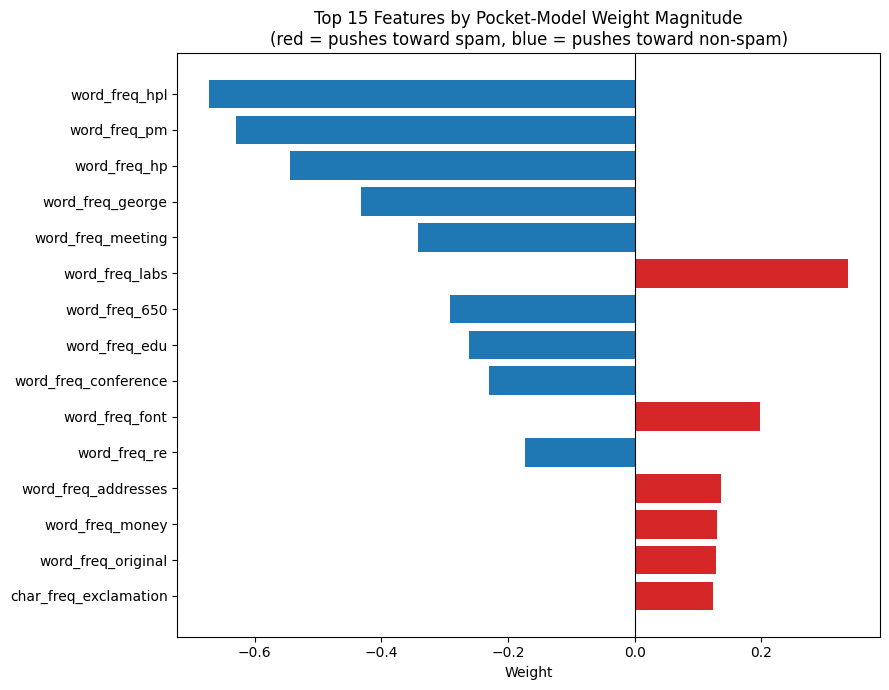

word_freq_hpl           -0.6715
word_freq_pm            -0.6298
word_freq_hp            -0.5443
word_freq_george        -0.4325
word_freq_meeting       -0.3418
word_freq_labs           0.3369
word_freq_650           -0.2920
word_freq_edu           -0.2615
word_freq_conference    -0.2306
word_freq_font           0.1973
word_freq_re            -0.1739
word_freq_addresses      0.1360
word_freq_money          0.1292
word_freq_original       0.1282
char_freq_exclamation    0.1234


In [78]:

weights_series = pd.Series(model.best_weights_, index=feature_columns)
top15 = weights_series.reindex(weights_series.abs().sort_values(ascending=False).index[:15])

plt.figure(figsize=(9, 7))
colors = ["tab:red" if v > 0 else "tab:blue" for v in top15.values]
plt.barh(top15.index[::-1], top15.values[::-1], color=colors[::-1])
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Top 15 Features by Pocket-Model Weight Magnitude\n(red = pushes toward spam, blue = pushes toward non-spam)")
plt.xlabel("Weight")
plt.tight_layout()
plt.show()

print(top15.round(4).to_string())

# 33. Compare with scikit-learn's perceptron

In [79]:

sk_model = SklearnPerceptron(
    eta0=0.01,
    max_iter=100,
    tol=None,
    shuffle=True,
    random_state=RANDOM_STATE,
    fit_intercept=True,
)

sk_model.fit(X_train, y_train)
sk_predictions = sk_model.predict(X_test)

comparison = pd.DataFrame({
    "Manual pocket": pocket_metrics,
    "Manual final epoch": final_metrics,
    "scikit-learn": metric_summary(y_test, sk_predictions),
}).T

print(comparison.round(4).to_string())

                    Accuracy  Precision  Recall      F1
Manual pocket         0.8546     0.7331  0.6479  0.6879
Manual final epoch    0.8583     0.7192  0.7004  0.7097
scikit-learn          0.8343     0.6913  0.5955  0.6398


# 34. Visual 17: Model comparison

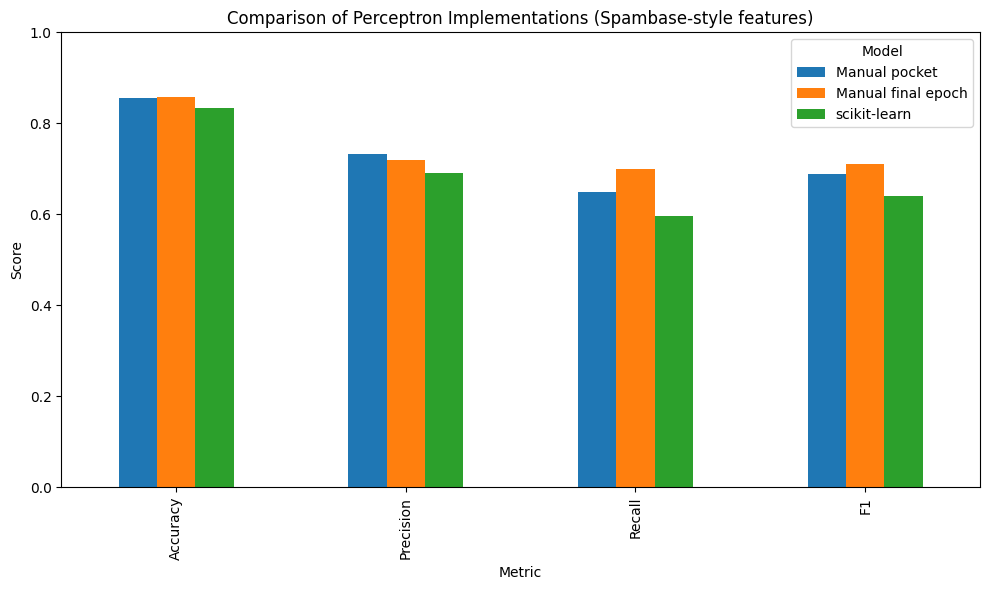

In [80]:

comparison.T.plot(kind="bar", figsize=(10, 6))
plt.ylim(0, 1)
plt.title("Comparison of Perceptron Implementations (Spambase-style features)")
plt.xlabel("Metric")
plt.ylabel("Score")
plt.legend(title="Model")
plt.tight_layout()
plt.show()

# 35. Reproducibility summary

In [81]:

print("=" * 78)
print("PERCEPTRON ASSESSMENT LAB COMPLETED — SPAMBASE-STYLE EMAIL CLASSIFICATION")
print("=" * 78)
print("Random seed                 :", RANDOM_STATE)
print("Engineered features         :", len(feature_columns))
print("Training observations       :", len(X_train))
print("Test observations           :", len(X_test))
print("Epochs completed            :", len(model.errors_per_epoch_))
print("Classical model converged   :", model.converged_)
print("Best training error count   :", model.best_errors_)
print("Pocket-model test accuracy  :", round(pocket_metrics["Accuracy"], 4))
print("Pocket-model test F1        :", round(pocket_metrics["F1"], 4))
print("=" * 78)

PERCEPTRON ASSESSMENT LAB COMPLETED — SPAMBASE-STYLE EMAIL CLASSIFICATION
Random seed                 : 42
Engineered features         : 57
Training observations       : 4648
Test observations           : 1080
Epochs completed            : 100
Classical model converged   : False
Best training error count   : 647
Pocket-model test accuracy  : 0.8546
Pocket-model test F1        : 0.6879
